#Julia - Data Cleaning, Pre-Processing, Preliminary Feature Engineering

#1.0 importing dataset and necessary libraries

1.1 saving an original version dataframe, and a new df with dropped columns.

1.2 potentially, create diff dfs based off what we need to analyze? (MAY NOT BE NECCESSARY)

In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("shivamb/5minute-crafts-video-views-dataset")

print("Files in dataset directory:")
print(os.listdir(path))

csv_path = os.path.join(path, "5-Minute Crafts.csv")
df = pd.read_csv(csv_path)

Files in dataset directory:
['5-Minute Crafts.csv']


In [ ]:
new_df = df.copy()

In [ ]:
new_df.drop('video_id', axis=1, inplace=True)
new_df.head()

,title,active_since_days,duration_seconds,total_views,num_chars,num_words,num_punctuation,num_words_uppercase,num_words_lowercase,num_stopwords,avg_word_len,contain_digits,startswith_digits,title_sentiment
0,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,22,623,295614,60,12,2,4,0,2,5.000000,0,0,0.144444
1,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,1,739,130544,87,17,4,5,0,3,5.117647,0,0,0.086905
2,HELPFUL LIFE HACKS FOR YOUR HOUSE,1,960,17834,33,6,0,6,0,2,5.500000,0,0,0.000000
3,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,30,833,3128867,66,12,2,5,0,3,5.500000,0,0,0.058333
4,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,15,3600,4210362,56,10,1,5,0,4,5.600000,0,0,0.500000


#1.1 numerical feature engineering

##1.1.1 view_quant column creation

smallest view amount - 4034

largest view amount - 283031109

goal: make a column that aggregates total views into one of 5 categories

1.   low views
2.   medium-low views
3.   medium views
4.   medium-high views
5.   high views

I am using quantile bining to achieve this goal, because the distribution is heavily skewed otherwise, with only 1 video in the large and small categories.

In [ ]:
# code used to determine the smallest and largest view counts
# new_df.loc[new_df['total_views'].idxmin()]
# new_df.loc[new_df['total_views'].idxmax()]

In [ ]:
# calculate view_category_quantile using total_views
new_df['view_category_quantile'] = pd.qcut(
    new_df['total_views'],
    q=5,
    labels=[0, 1, 2, 3, 4]
).astype(int)

# distribution of categories
display(new_df['view_category_quantile'].value_counts().sort_index())

# check on the full DataFrame structure
new_df.head(10)


,count
view_category_quantile,
0,996
1,995
2,996
3,995
4,996


,title,active_since_days,duration_seconds,total_views,num_chars,num_words,num_punctuation,num_words_uppercase,num_words_lowercase,num_stopwords,avg_word_len,contain_digits,startswith_digits,title_sentiment,view_category_quantile
0,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,22,623,295614,60,12,2,4,0,2,5.000000,0,0,0.144444,0
1,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,1,739,130544,87,17,4,5,0,3,5.117647,0,0,0.086905,0
2,HELPFUL LIFE HACKS FOR YOUR HOUSE,1,960,17834,33,6,0,6,0,2,5.500000,0,0,0.000000,0
3,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,30,833,3128867,66,12,2,5,0,3,5.500000,0,0,0.058333,3
4,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,15,3600,4210362,56,10,1,5,0,4,5.600000,0,0,0.500000,3
5,100+ HACKS & GADGETS FOR COOL PARENTS,6,3600,90733,37,7,2,5,0,1,5.285714,1,1,0.350000,0
6,30 BEST HACKS FOR EVERY LIFE SITUATION,60,900,1081439,38,7,0,6,0,1,5.428571,1,1,1.000000,2
7,KID'S ROOM MAKEOVER IDEAS || Awesome Home Deco...,2,3660,582492,58,9,3,4,0,0,6.444444,0,0,1.000000,1
8,Brilliant Clothing Hacks For Adults and Their ...,3,900,471701,50,8,0,0,1,3,6.250000,0,0,0.900000,1
9,BRILLIANT LIFE HACKS FOR ANY SITUATION,90,3600,11175800,38,6,0,6,0,2,6.333333,0,0,0.900000,4


##1.1.2 views_by_day

the videos have been available for different numbers of days. while it is good to have a range, this can lead to problems as a video that got 100k views in 1 day versus 200k views over 200 days have extremely different levels of virality: to counteract that, the **views_by_day** column looks at how many views the video averages per day.

In [ ]:
# stop division by zero
new_df['active_since_days'] = new_df['active_since_days'].replace(0, 1)

# new views_per_day column
# used int division just for sake of cleanliness
new_df['views_by_day'] = new_df['total_views'] // new_df['active_since_days']

In [ ]:
new_df.head()

,title,active_since_days,duration_seconds,total_views,num_chars,num_words,num_punctuation,num_words_uppercase,num_words_lowercase,num_stopwords,avg_word_len,contain_digits,startswith_digits,title_sentiment,view_category_quantile,views_by_day
0,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,22,623,295614,60,12,2,4,0,2,5.000000,0,0,0.144444,0,13437
1,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,1,739,130544,87,17,4,5,0,3,5.117647,0,0,0.086905,0,130544
2,HELPFUL LIFE HACKS FOR YOUR HOUSE,1,960,17834,33,6,0,6,0,2,5.500000,0,0,0.000000,0,17834
3,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,30,833,3128867,66,12,2,5,0,3,5.500000,0,0,0.058333,3,104295
4,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,15,3600,4210362,56,10,1,5,0,4,5.600000,0,0,0.500000,3,280690


# 1.2 pre-processing title for nlp

I am creating 2 versions of the title column, **title_original** and **title_clean**, so we have one case sensitive version that we can use for case analysis (title_orginal) and one version we can use for nlp processing (title_clean)

In [ ]:
import re

# preserving the original title for case analysis
new_df['title_original'] = new_df['title']

# create a function to clean each title in the dataset, by lowering, removing punctutation and stripping whitespace
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()  # normalize whitespace
    return text

# applying function to dataset
new_df['title_clean'] = new_df['title'].apply(clean_text)

new_df.drop("title", axis=1, inplace=True)

new_df.head()

,active_since_days,duration_seconds,total_views,num_chars,num_words,num_punctuation,num_words_uppercase,num_words_lowercase,num_stopwords,avg_word_len,contain_digits,startswith_digits,title_sentiment,view_category_quantile,views_by_day,title_original,title_clean
0,22,623,295614,60,12,2,4,0,2,5.000000,0,0,0.144444,0,13437,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,super lazy life hacks cool hacks to make your ...
1,1,739,130544,87,17,4,5,0,3,5.117647,0,0,0.086905,0,130544,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,yum easy smart food hacks tasty recipes for th...
2,1,960,17834,33,6,0,6,0,2,5.500000,0,0,0.000000,0,17834,HELPFUL LIFE HACKS FOR YOUR HOUSE,helpful life hacks for your house
3,30,833,3128867,66,12,2,5,0,3,5.500000,0,0,0.058333,3,104295,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,useful hacks for your home simple tips that wo...
4,15,3600,4210362,56,10,1,5,0,4,5.600000,0,0,0.500000,3,280690,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,are you a crafty mom amazing parenting hacks a...


##1.2.1 re-organizing columns based on general topic

In [ ]:
# define column reordering
cols = list(new_df.columns)

# remove the columns to reposition
cols.remove('title_original')
cols.remove('title_clean')
cols.remove('view_category_quantile')
cols.remove('views_by_day')

# reinsert in desired order
# move 'title_original' and 'title_clean' to start
new_order = ['title_original', 'title_clean'] + cols

# insert 'views_by_day' after 'total_views'
# insert 'view_category_quantile' after 'views_by_day'
insert_at = new_order.index('total_views') + 1
new_order.insert(insert_at, 'views_by_day')
new_order.insert(insert_at + 1, 'view_category_quantile')

# reorder the DataFrame
new_df = new_df[new_order]

# result
new_df.head()


,title_original,title_clean,active_since_days,duration_seconds,total_views,views_by_day,view_category_quantile,num_chars,num_words,num_punctuation,num_words_uppercase,num_words_lowercase,num_stopwords,avg_word_len,contain_digits,startswith_digits,title_sentiment
0,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,super lazy life hacks cool hacks to make your ...,22,623,295614,13437,0,60,12,2,4,0,2,5.000000,0,0,0.144444
1,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,yum easy smart food hacks tasty recipes for th...,1,739,130544,130544,0,87,17,4,5,0,3,5.117647,0,0,0.086905
2,HELPFUL LIFE HACKS FOR YOUR HOUSE,helpful life hacks for your house,1,960,17834,17834,0,33,6,0,6,0,2,5.500000,0,0,0.000000
3,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,useful hacks for your home simple tips that wo...,30,833,3128867,104295,3,66,12,2,5,0,3,5.500000,0,0,0.058333
4,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,are you a crafty mom amazing parenting hacks a...,15,3600,4210362,280690,3,56,10,1,5,0,4,5.600000,0,0,0.500000


# 2.0 tokenization

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
new_df['title_tokens'] = new_df['title_clean'].apply(word_tokenize)

In [ ]:
new_df['title_tokens'].head()

,title_tokens
0,"[super, lazy, life, hacks, cool, hacks, to, ma..."
1,"[yum, easy, smart, food, hacks, tasty, recipes..."
2,"[helpful, life, hacks, for, your, house]"
3,"[useful, hacks, for, your, home, simple, tips,..."
4,"[are, you, a, crafty, mom, amazing, parenting,..."


# 3.0 lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()

new_df['title_lemmas'] = new_df['title_tokens'].apply(lambda tokens: [lemmatizer.lemmatize(t) for t in tokens])

In [ ]:
new_df['title_lemmas'].head()

,title_lemmas
0,"[super, lazy, life, hack, cool, hack, to, make..."
1,"[yum, easy, smart, food, hack, tasty, recipe, ..."
2,"[helpful, life, hack, for, your, house]"
3,"[useful, hack, for, your, home, simple, tip, t..."
4,"[are, you, a, crafty, mom, amazing, parenting,..."


# 4.0 text based feature engineering

In [ ]:
new_df['has_question'] = new_df['title_original'].str.contains(r'\?').astype(int)
new_df['has_exclamation'] = new_df['title_original'].str.contains(r'!').astype(int)
new_df['uppercase_ratio'] = new_df['num_words_uppercase'] / new_df['num_words']

In [ ]:
new_df.head()

,title_original,title_clean,active_since_days,duration_seconds,total_views,views_by_day,view_category_quantile,num_chars,num_words,num_punctuation,...,num_stopwords,avg_word_len,contain_digits,startswith_digits,title_sentiment,title_tokens,title_lemmas,has_question,has_exclamation,uppercase_ratio
0,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,super lazy life hacks cool hacks to make your ...,22,623,295614,13437,0,60,12,2,...,2,5.000000,0,0,0.144444,"[super, lazy, life, hacks, cool, hacks, to, ma...","[super, lazy, life, hack, cool, hack, to, make...",0,0,0.333333
1,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,yum easy smart food hacks tasty recipes for th...,1,739,130544,130544,0,87,17,4,...,3,5.117647,0,0,0.086905,"[yum, easy, smart, food, hacks, tasty, recipes...","[yum, easy, smart, food, hack, tasty, recipe, ...",0,1,0.294118
2,HELPFUL LIFE HACKS FOR YOUR HOUSE,helpful life hacks for your house,1,960,17834,17834,0,33,6,0,...,2,5.500000,0,0,0.000000,"[helpful, life, hacks, for, your, house]","[helpful, life, hack, for, your, house]",0,0,1.000000
3,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,useful hacks for your home simple tips that wo...,30,833,3128867,104295,3,66,12,2,...,3,5.500000,0,0,0.058333,"[useful, hacks, for, your, home, simple, tips,...","[useful, hack, for, your, home, simple, tip, t...",0,0,0.416667
4,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,are you a crafty mom amazing parenting hacks a...,15,3600,4210362,280690,3,56,10,1,...,4,5.600000,0,0,0.500000,"[are, you, a, crafty, mom, amazing, parenting,...","[are, you, a, crafty, mom, amazing, parenting,...",1,0,0.500000


#4.1 UPDATED FEATURE ENGINEERING - 4/18 (post midpoint check in)

- implemented CountVectorizer, TFIDFVectorizer, GLoVE Embeddings and Specific Stylistic Feature: UpperCase count & Curse Word Count

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
count_vectorizer = CountVectorizer(max_features=5000)
count_features = count_vectorizer.fit_transform(new_df['title_clean'])

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_features = tfidf_vectorizer.fit_transform(new_df['title_clean'])

In [ ]:
#!pip uninstall -y numpy scipy gensim
#!pip install numpy==1.24.3 scipy==1.10.1 gensim==4.3.1

Found existing installation: numpy 1.24.3
Uninstalling numpy-1.24.3:
  Successfully uninstalled numpy-1.24.3
Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Successfully uninstalled scipy-1.14.1
Found existing installation: gensim 4.3.1
Uninstalling gensim-4.3.1:
  Successfully uninstalled gensim-4.3.1
  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 4.5 MB/s eta 0:00:00
  Using cached gensim-4.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.4 kB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 20.0 MB/s eta 0:00:00
Using cached gensim-4.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This be

In [ ]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import re
import nltk

In [ ]:
import gensim.downloader as api

In [ ]:
# if running this code, make sure to uncomment the below line, as i had to run the code multiple times, this was commented out
# glove_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
import numpy as np

In [ ]:
# get GLoVE embeddings for more advanced feature engineering
def get_glove_vector(text):
    words = text.split()
    vectors = [glove_model[word] for word in words if word in glove_model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(100)

glove_vectors = new_df['title_clean'].apply(get_glove_vector)
glove_matrix = np.vstack(glove_vectors.values)

In [ ]:
# grabs cursewords and num caps
def stylistic_features(text):
    num_capitals = sum(1 for c in text if c.isupper())
    num_swears = sum(1 for word in text.lower().split() if word in {'damn', 'hell', 'crap', 'shit', 'fuck'})
    return pd.Series([num_capitals, num_swears])

In [ ]:
new_df[['capital_count', 'swear_word_count']] = new_df['title_original'].apply(stylistic_features)

In [ ]:
# checking if al ladvanced features work -> observation : no swear words used
print("Count Vectorizer shape:", count_features.shape)
print("TF-IDF shape:", tfidf_features.shape)
print("GloVe matrix shape:", glove_matrix.shape)
print(new_df[['capital_count', 'swear_word_count']].head())

Count Vectorizer shape: (4978, 2114)
TF-IDF shape: (4978, 2114)
GloVe matrix shape: (4978, 100)
   capital_count  swear_word_count
0             25                 0
1             31                 0
2             28                 0
3             28                 0
4             21                 0


In [ ]:
new_df.head()

,title_original,title_clean,active_since_days,duration_seconds,total_views,views_by_day,view_category_quantile,num_chars,num_words,num_punctuation,...,contain_digits,startswith_digits,title_sentiment,title_tokens,title_lemmas,has_question,has_exclamation,uppercase_ratio,capital_count,swear_word_count
0,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,super lazy life hacks cool hacks to make your ...,22,623,295614,13437,0,60,12,2,...,0,0,0.144444,"[super, lazy, life, hacks, cool, hacks, to, ma...","[super, lazy, life, hack, cool, hack, to, make...",0,0,0.333333,25,0
1,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,yum easy smart food hacks tasty recipes for th...,1,739,130544,130544,0,87,17,4,...,0,0,0.086905,"[yum, easy, smart, food, hacks, tasty, recipes...","[yum, easy, smart, food, hack, tasty, recipe, ...",0,1,0.294118,31,0
2,HELPFUL LIFE HACKS FOR YOUR HOUSE,helpful life hacks for your house,1,960,17834,17834,0,33,6,0,...,0,0,0.000000,"[helpful, life, hacks, for, your, house]","[helpful, life, hack, for, your, house]",0,0,1.000000,28,0
3,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,useful hacks for your home simple tips that wo...,30,833,3128867,104295,3,66,12,2,...,0,0,0.058333,"[useful, hacks, for, your, home, simple, tips,...","[useful, hack, for, your, home, simple, tip, t...",0,0,0.416667,28,0
4,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,are you a crafty mom amazing parenting hacks a...,15,3600,4210362,280690,3,56,10,1,...,0,0,0.500000,"[are, you, a, crafty, mom, amazing, parenting,...","[are, you, a, crafty, mom, amazing, parenting,...",1,0,0.500000,21,0


In [ ]:
new_df.to_csv('cleaned_dataset.csv', index=False)

#Serena - Exploratory Data Analysis

# 5.0 Define Engagement Levels Using Total_Views Thresholds

In [ ]:
# Calculate thresholds for 25th and 75th percentiles
low_threshold = new_df['total_views'].quantile(0.25)
high_threshold = new_df['total_views'].quantile(0.75)

# Create a column 'engagement' based on these thresholds
def set_engagement(views):
    if views <= low_threshold:
        return 'low'
    elif views >= high_threshold:
        return 'high'
    else:
        return 'medium'

new_df['engagement'] = new_df['total_views'].apply(set_engagement)

# Check engagement
print(new_df['engagement'].value_counts())

engagement
medium    2488
low       1245
high      1245
Name: count, dtype: int64


# 6.0 TF-IDF Analysis for High vs. Low Engagement Titles

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

low_titles = new_df[new_df['engagement'] == 'low']['title_clean']
high_titles = new_df[new_df['engagement'] == 'high']['title_clean']

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1), lowercase=True)

combined_titles = pd.concat([low_titles, high_titles])
tfidf_vectorizer.fit(combined_titles)

# Transform
low_tfidf = tfidf_vectorizer.transform(low_titles)
high_tfidf = tfidf_vectorizer.transform(high_titles)

In [ ]:
# Get average TF-IDF for each term for low and high groups

low_avg_tfidf = np.array(low_tfidf.mean(axis=0))[0]
high_avg_tfidf = np.array(high_tfidf.mean(axis=0))[0]

# Inverse mapping to display the word with its score
inv_vocab = {index: word for word, index in tfidf_vectorizer.vocabulary_.items()}

# 5. Find the indices of the top 10 words in low and high groups
n = 10
low_top_indices = low_avg_tfidf.argsort()[::-1][:n]
high_top_indices = high_avg_tfidf.argsort()[::-1][:n]

print("Top 10 words in low engagement titles:")
for idx in low_top_indices:
    print(inv_vocab[idx], low_avg_tfidf[idx])

print("Top 10 words in high engagement titles:")
for idx in high_top_indices:
    print(inv_vocab[idx], high_avg_tfidf[idx])

Top 10 words in low engagement titles:
hacks 0.05338602371735018
to 0.04896801841835081
your 0.042370924365891655
for 0.040138530785873476
you 0.039056055755792594
crafts 0.03709060627241349
and 0.03514112321281613
life 0.032103475065759855
that 0.03142726589793135
5minute 0.031041843050428185
Top 10 words in high engagement titles:
hacks 0.08056388698016709
life 0.048447677122677765
you 0.043085392451344774
to 0.042218906121306174
and 0.041163184155516466
for 0.03720729355890189
your 0.03672091950175723
that 0.032416434997285117
25 0.027658562654855865
ideas 0.02673916588528842


# 7.0 Analyze the Impact of Title Length and Visualize Patterns

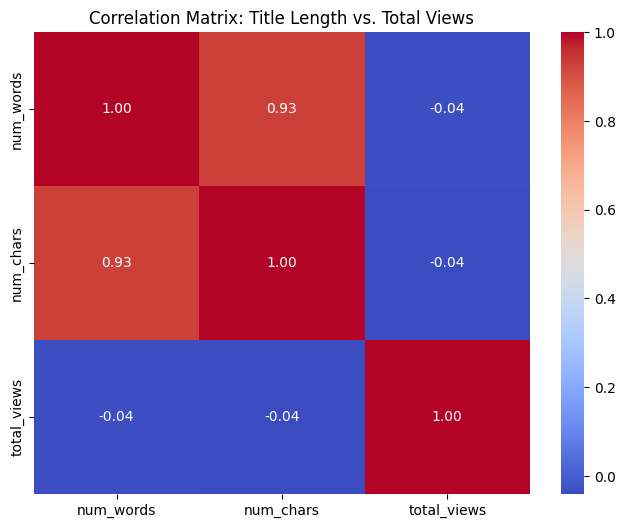

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns for dataframe
numeric_cols = ['num_words', 'num_chars', 'total_views']
data_subset = new_df[numeric_cols]

correlation_matrix = data_subset.corr()

# Plot the heatmap to visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Title Length vs. Total Views")
plt.show()

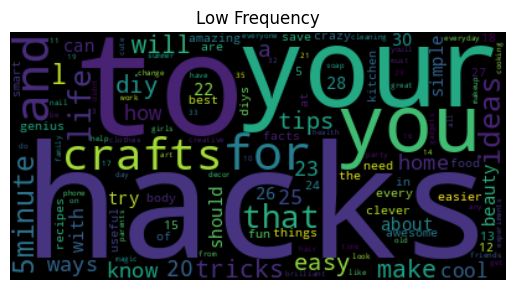

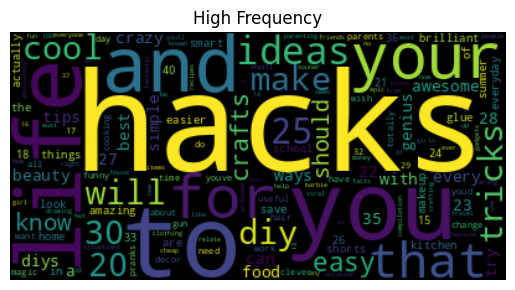

In [ ]:
from collections import Counter
from wordcloud import WordCloud

# Combine all titles into one string
low_text = " ".join(low_titles.tolist())
high_text = " ".join(high_titles.tolist())

# Build frequency dictionaries
low_freq = {}
for word in low_text.split():
    low_freq[word] = low_freq.get(word, 0) + 1

high_freq = {}
for word in high_text.split():
    high_freq[word] = high_freq.get(word, 0) + 1

# Function to create and display a word cloud from a frequency dictionary
def create_wordcloud(word_freq, title):
    wordcloud = WordCloud()
    wordcloud.generate_from_frequencies(frequencies=word_freq)
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Create word clouds for each engagement group
create_wordcloud(low_freq, "Low Frequency")
create_wordcloud(high_freq, "High Frequency")